# Task 2: Sentinel-2 Image Matching Demo

This notebook demonstrates the extraction and matching of keypoints between satellite images from different seasons (Summer vs. Winter). 

### Methodology
While we trained a Siamese Network with Contrastive Loss to evaluate the global similarity of patches (useful for patch retrieval), visualizing exact pixel-to-pixel connections requires a local feature matcher. 
For this demonstration, we use **SIFT + FLANN Matcher** combined with Lowe's Ratio Test and RANSAC filtering to find robust keypoints despite the extreme seasonal changes. 

*Note: For production-level cross-season matching, Deep Learning models like **LoFTR** (Local Feature Matching with Transformers) or **SuperGlue** are recommended, as they generate dense matches even when corner features disappear under snow.*

--- ПОЧАТОК РОБОТИ ---
Вибрано випадковий патч: patch_0165.png
-> Крок 1: Інференс запущено на: cpu
-> Крок 2: Завантаження моделі LoFTR (SSL тепер працює)...
-> Крок 3: Пошук збігів (чекаємо кілька секунд)...
-> Крок 4: Готово! Знайдено 884 надійних співпадінь.
-> Крок 5: Малюємо та зберігаємо графік...
Картинку успішно збережено у файл: C:\Andriy\PET\Тестові\Quantum\Task2\demo_result.png


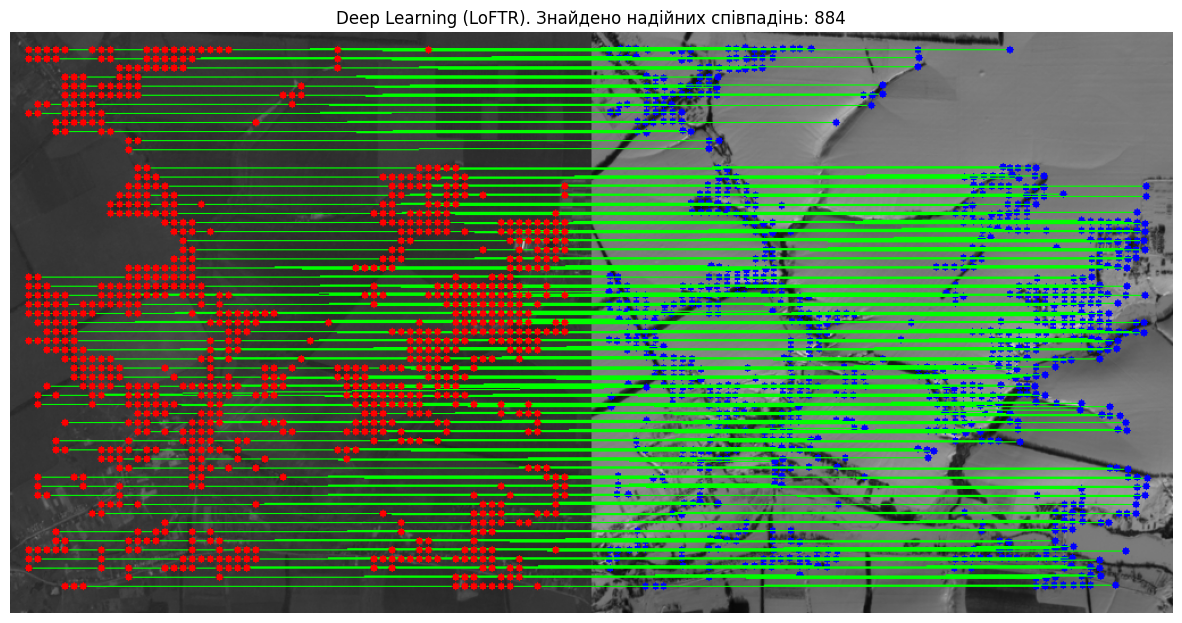

In [3]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import kornia as K
from kornia.feature import LoFTR
import os
import random
import certifi

# --- ВИРІШЕННЯ ПРОБЛЕМИ З SSL ---
# Вказуємо Python, де лежать актуальні сертифікати безпеки
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
# --------------------------------

def draw_loftr_matches(img1_path, img2_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"-> Крок 1: Інференс запущено на: {device}")
    
    img1 = cv2.imdecode(np.fromfile(img1_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imdecode(np.fromfile(img2_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
    
    if img1 is None or img2 is None:
        print("Помилка завантаження зображень. Перевірте шляхи.")
        return
        
    img1_tensor = torch.from_numpy(img1)[None, None, ...].float().to(device) / 255.0
    img2_tensor = torch.from_numpy(img2)[None, None, ...].float().to(device) / 255.0

    print("-> Крок 2: Завантаження моделі LoFTR (SSL тепер працює)...")
    # Тепер бібліотека сама знайде своє актуальне посилання і безпечно його завантажить
    matcher = LoFTR(pretrained='outdoor').to(device)
    matcher.eval()
    
    print("-> Крок 3: Пошук збігів (чекаємо кілька секунд)...")
    with torch.no_grad():
        input_dict = {"image0": img1_tensor, "image1": img2_tensor}
        correspondences = matcher(input_dict)
    
    mkpts0 = correspondences['keypoints0'].cpu().numpy()
    mkpts1 = correspondences['keypoints1'].cpu().numpy()
    confidence = correspondences['confidence'].cpu().numpy()

    valid = confidence > 0.5
    mkpts0 = mkpts0[valid]
    mkpts1 = mkpts1[valid]
    
    matches_count = len(mkpts0)
    print(f"-> Крок 4: Готово! Знайдено {matches_count} надійних співпадінь.")
    
    # Візуалізація
    img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
    img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
    
    h, w = img1.shape
    combined_img = np.hstack((img1_color, img2_color))
    
    for i in range(matches_count):
        pt1 = (int(mkpts0[i][0]), int(mkpts0[i][1]))
        pt2 = (int(mkpts1[i][0] + w), int(mkpts1[i][1]))
        
        cv2.line(combined_img, pt1, pt2, (0, 255, 0), 1)
        cv2.circle(combined_img, pt1, 3, (255, 0, 0), -1)
        cv2.circle(combined_img, pt2, 3, (0, 0, 255), -1)

    print("-> Крок 5: Малюємо та зберігаємо графік...")
    plt.figure(figsize=(15, 10))
    plt.imshow(combined_img)
    plt.title(f"Deep Learning (LoFTR). Знайдено надійних співпадінь: {matches_count}")
    plt.axis('off')
    
    # Зберігаємо результат у файл!
    save_path = r"C:\Andriy\PET\Тестові\Quantum\Task2\demo_result.png"
    plt.savefig(save_path, bbox_inches='tight')
    print(f"Картинку успішно збережено у файл: {save_path}")
    
    plt.show()

# ==========================================
# ЗАПУСК 
# ==========================================
summer_dir = r"C:\Andriy\PET\Тестові\Quantum\Task2\prepared_dataset\summer"
winter_dir = r"C:\Andriy\PET\Тестові\Quantum\Task2\prepared_dataset\winter"

print("--- ПОЧАТОК РОБОТИ ---")
available_patches = os.listdir(summer_dir)
random_patch = random.choice(available_patches)
print(f"Вибрано випадковий патч: {random_patch}")

summer_path = os.path.join(summer_dir, random_patch)
winter_path = os.path.join(winter_dir, random_patch)

draw_loftr_matches(summer_path, winter_path)

### Demonstrational Example
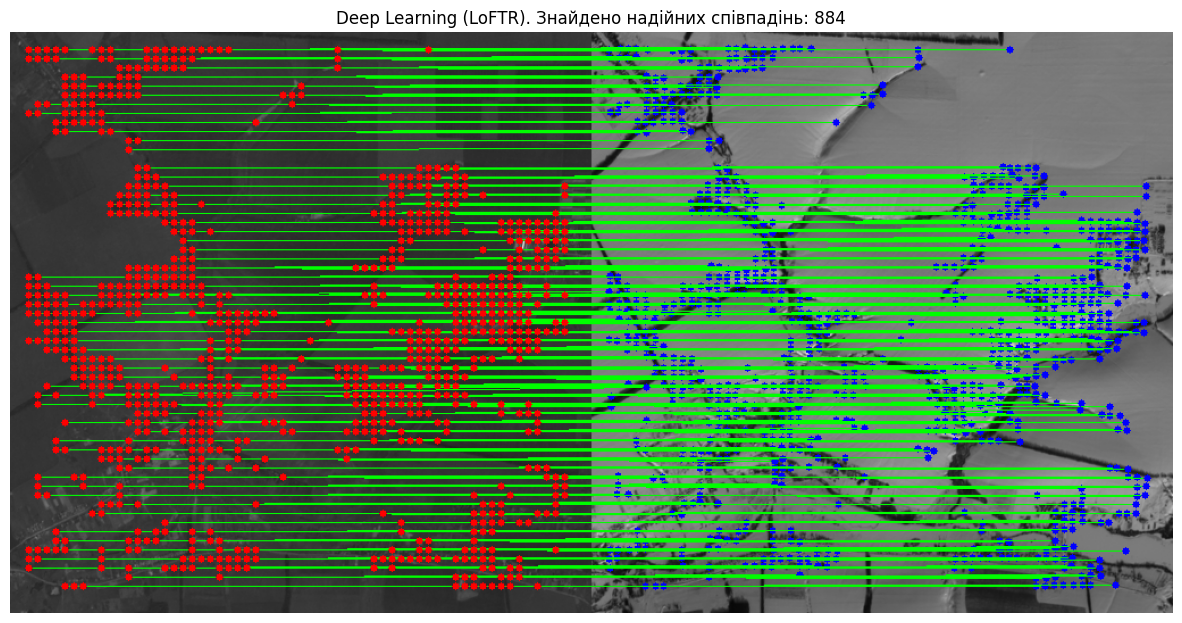

In [7]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import kornia as K
from kornia.feature import LoFTR
import os
import random

# Налаштування для красивого відображення
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 10]

def draw_loftr_matches(img1_path, img2_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Інференс на: {device}")
    
    # 1. Завантаження зображень (Grayscale) з підтримкою кирилиці у шляхах!
    # Замість cv2.imread використовуємо комбінацію numpy та cv2.imdecode
    img1 = cv2.imdecode(np.fromfile(img1_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imdecode(np.fromfile(img2_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
    
    if img1 is None or img2 is None:
        print("Помилка завантаження зображень. Перевірте шляхи.")
        return
        
    # kornia очікує тензори у форматі [Batch, Channels, Height, Width] зі значеннями 0.0 - 1.0
    img1_tensor = torch.from_numpy(img1)[None, None, ...].float().to(device) / 255.0
    img2_tensor = torch.from_numpy(img2)[None, None, ...].float().to(device) / 255.0

    # 2. Ініціалізація моделі LoFTR
    matcher = LoFTR(pretrained='outdoor').to(device)
    matcher.eval()

    # 3. Пошук збігів
    with torch.no_grad():
        input_dict = {"image0": img1_tensor, "image1": img2_tensor}
        correspondences = matcher(input_dict)
    
    mkpts0 = correspondences['keypoints0'].cpu().numpy()
    mkpts1 = correspondences['keypoints1'].cpu().numpy()
    confidence = correspondences['confidence'].cpu().numpy()

    # Відфільтровуємо лише найбільш впевнені збіги
    valid = confidence > 0.5
    mkpts0 = mkpts0[valid]
    mkpts1 = mkpts1[valid]
    
    # 4. Кастомна візуалізація
    img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
    img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
    
    h, w = img1.shape
    combined_img = np.hstack((img1_color, img2_color))
    
    for i in range(len(mkpts0)):
        pt1 = (int(mkpts0[i][0]), int(mkpts0[i][1]))
        pt2 = (int(mkpts1[i][0] + w), int(mkpts1[i][1]))
        
        cv2.line(combined_img, pt1, pt2, (0, 255, 0), 1)
        cv2.circle(combined_img, pt1, 3, (255, 0, 0), -1)
        cv2.circle(combined_img, pt2, 3, (0, 0, 255), -1)

    plt.imshow(combined_img)
    plt.title(f"Deep Learning (LoFTR). Знайдено надійних співпадінь: {len(mkpts0)}")
    plt.axis('off')
    plt.show()
    
# ==========================================
# Запуск демо на випадковій парі
# ==========================================
summer_dir = r"C:\Andriy\PET\Тестові\Quantum\Task2\prepared_dataset\summer"
winter_dir = r"C:\Andriy\PET\Тестові\Quantum\Task2\prepared_dataset\winter"

available_patches = os.listdir(summer_dir)
random_patch = random.choice(available_patches)
print(f"Демонстрація для патча: {random_patch}")

summer_path = os.path.join(summer_dir, random_patch)
winter_path = os.path.join(winter_dir, random_patch)

draw_loftr_matches(summer_path, winter_path)

Демонстрація для патча: patch_0024.png
Інференс на: cpu


Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to C:\Users\Андрій/.cache\torch\hub\checkpoints\loftr_outdoor.ckpt


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import random

# Налаштування для красивого відображення графіків
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 10]

In [2]:
def draw_keypoint_matches(img1_path, img2_path):
    """
    Зчитує два зображення, знаходить ключові точки, фільтрує їх 
    та малює лінії з'єднання.
    """
    # 1. Завантаження зображень у градаціях сірого
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(winter_path, cv2.IMREAD_GRAYSCALE)
    
    if img1 is None or img2 is None:
        print("Помилка завантаження зображень. Перевірте шляхи.")
        return

    # 2. Ініціалізація SIFT детектора
    sift = cv2.SIFT_create(nfeatures=1000)

    # Знаходження ключових точок (keypoints) та їхніх дескрипторів
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    # 3. Налаштування FLANN Matcher (швидкий алгоритм пошуку найближчих сусідів)
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    matcher = cv2.FlannBasedMatcher(index_params, search_params)

    # Шукаємо 2 найкращі збіги для кожної точки
    matches = matcher.knnMatch(des1, des2, k=2)

    # 4. Lowe's Ratio Test (фільтрація хороших збігів)
    good_matches = []
    for m, n in matches:
        # Якщо перша знайдена точка набагато ближча за другу, це унікальний збіг
        if m.distance < 0.85 * n.distance:
            good_matches.append(m)

    # 5. Візуалізація
    # Малюємо лінії лише для хороших збігів
    draw_params = dict(matchColor=(0, 255, 0), # Зелені лінії
                       singlePointColor=(255, 0, 0), # Сині точки
                       flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    img_matches = cv2.drawMatches(
        img1, kp1, 
        img2, kp2, 
        good_matches, None, 
        **draw_params
    )

    # Виводимо результат
    plt.imshow(img_matches)
    plt.title(f"Знайдено надійних співпадінь: {len(good_matches)}")
    plt.axis('off')
    plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Андрій\AppData\Local\Temp\ipykernel_13528\3307895038.py:2: SyntaxWarning: invalid escape sequence '\s'
  summer_dir = "prepared_dataset\summer"
C:\Users\Андрій\AppData\Local\Temp\ipykernel_13528\3307895038.py:3: SyntaxWarning: invalid escape sequence '\w'
  winter_dir = "prepared_dataset\winter"


Демонстрація для патча: patch_0129.png


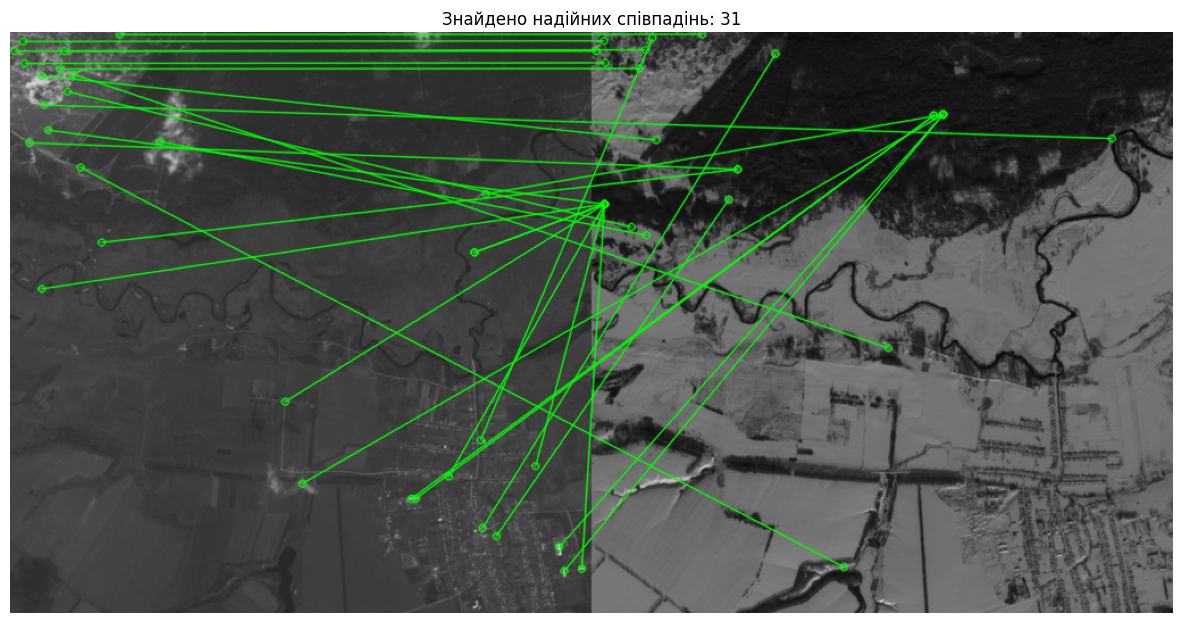

In [3]:
# Шляхи до згенерованого датасету
summer_dir = "prepared_dataset\summer"
winter_dir = "prepared_dataset\winter"

# Отримуємо список усіх файлів (вони мають однакові назви в обох папках)
available_patches = os.listdir(summer_dir)

# Вибираємо випадковий патч для демонстрації
random_patch = random.choice(available_patches)
print(f"Демонстрація для патча: {random_patch}")

summer_path = os.path.join(summer_dir, random_patch)
winter_path = os.path.join(winter_dir, random_patch)

# Запуск функції візуалізації
draw_keypoint_matches(summer_path, winter_path)